In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report,confusion_matrix, roc_auc_score, roc_curve)
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

print("Semua library berhasil diimport!")

Semua library berhasil diimport!


In [3]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/PA 3 KEL 10-20260406T061058Z-3-001/PA 3 KEL 10/ML/diabetes_dataset.csv')
print("Dataset berhasil dimuat!")
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
df.head()

Mounted at /content/drive
Dataset berhasil dimuat!
Jumlah baris: 100000
Jumlah kolom: 16


,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0


eksplorasi data (EDA)

In [4]:
df.info()
print("\n")
print(df.describe())
print("\nMissing values:")
print(df.isnull().sum())
print("\nDistribusi label:")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   year                  100000 non-null  int64  
 1   gender                100000 non-null  object 
 2   age                   100000 non-null  float64
 3   location              100000 non-null  object 
 4   race:AfricanAmerican  100000 non-null  int64  
 5   race:Asian            100000 non-null  int64  
 6   race:Caucasian        100000 non-null  int64  
 7   race:Hispanic         100000 non-null  int64  
 8   race:Other            100000 non-null  int64  
 9   hypertension          100000 non-null  int64  
 10  heart_disease         100000 non-null  int64  
 11  smoking_history       100000 non-null  object 
 12  bmi                   100000 non-null  float64
 13  hbA1c_level           100000 non-null  float64
 14  blood_glucose_level   100000 non-null  int64  
 15  d

In [5]:
print(df.isnull().sum())

year                    0
gender                  0
age                     0
location                0
race:AfricanAmerican    0
race:Asian              0
race:Caucasian          0
race:Hispanic           0
race:Other              0
hypertension            0
heart_disease           0
smoking_history         0
bmi                     0
hbA1c_level             0
blood_glucose_level     0
diabetes                0
dtype: int64


<Axes: ylabel='bmi'>

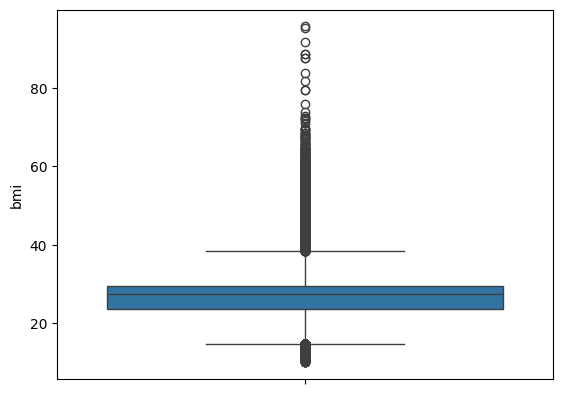

In [6]:
sns.boxplot(df['bmi'])

In [7]:
print(df['diabetes'].value_counts())

diabetes
0    91500
1     8500
Name: count, dtype: int64


In [8]:
print(df['smoking_history'].unique())
print(df[df['age'] < 10])

['never' 'not current' 'current' 'No Info' 'ever' 'former']
       year  gender   age location  race:AfricanAmerican  race:Asian  \
12     2015  Female  3.00  Alabama                     1           0   
16     2015  Female  2.00  Alabama                     0           1   
38     2015    Male  3.00  Alabama                     0           0   
40     2016    Male  8.00  Alabama                     0           1   
46     2015    Male  5.00  Alabama                     0           0   
...     ...     ...   ...      ...                   ...         ...   
99943  2016    Male  3.00  Wyoming                     0           1   
99944  2016  Female  2.00  Wyoming                     0           0   
99947  2016  Female  6.00  Wyoming                     1           0   
99983  2016    Male  5.00  Wyoming                     0           0   
99991  2016    Male  1.48  Wyoming                     0           0   

       race:Caucasian  race:Hispanic  race:Other  hypertension  heart_disea

# Preprocessing: Noise, Outlier, dan Data Imbalance

Handle Noise mengisi NaN dengan modus:

In [9]:
df['smoking_history'] = df['smoking_history'].replace(
    'No Info', 
    df[df['smoking_history'] != 'No Info']['smoking_history'].mode()[0]
)


In [11]:
print(df['smoking_history'].head())

0    never
1    never
2    never
3    never
4    never
Name: smoking_history, dtype: object


In [12]:
print(df['smoking_history'].value_counts())

smoking_history
never          70911
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64


Handle Outlier (menggunakan IQR pada kolom numerik)

In [14]:
def remove_outlier_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[column] >= lower) & (data[column] <= upper)]

for col in ['age', 'bmi', 'hbA1c_level', 'blood_glucose_level']:
    df = remove_outlier_iqr(df, col)

In [17]:
print("-" * 50 + f"\nTotal baris akhir setelah handling outlier: {len(df)}")

--------------------------------------------------
Total baris akhir setelah handling outlier: 84784


Handle Data Imbalance

In [18]:
X = df.drop('diabetes', axis=1)
y = df['diabetes']
# Label encoding untuk fitur kategorikal sebelum SMOTE
for col in X.select_dtypes(include=['object']).columns:
    X[col] = LabelEncoder().fit_transform(X[col])
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)
print('Sebelum SMOTE:', y.value_counts().to_dict())
print('Setelah SMOTE:', dict(zip(*np.unique(y_res, return_counts=True))))

Sebelum SMOTE: {0: 80751, 1: 4033}
Setelah SMOTE: {np.int64(0): np.int64(80751), np.int64(1): np.int64(80751)}


# Feature Engineering, Encoding, Scaling, dan Dimensionality Reduction

Feature Engineering (contoh: membuat fitur baru dari clinical_notes jika ada)

In [19]:
if 'clinical_notes' in df.columns:
    df['notes_length'] = df['clinical_notes'].astype(str).apply(len)

Encoding (Label Encoding untuk kolom kategorikal, OneHot untuk yang sedikit unik)

In [20]:

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'clinical_notes' in categorical_cols:
    categorical_cols.remove('clinical_notes') 
for col in categorical_cols:
    if df[col].nunique() <= 5:
        df = pd.get_dummies(df, columns=[col], drop_first=True)
    else:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))


Scaling/Normalisasi (StandardScaler untuk numerik)

In [21]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'diabetes' in numeric_cols:
    numeric_cols.remove('diabetes')
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])



Dimensionality Reduction (opsional, contoh dengan PCA)

In [22]:
do_pca = True 
if do_pca:
    pca = PCA(n_components=0.95, random_state=42)  # Simpan 95% variansi
    features = df.drop(['diabetes'], axis=1)
    features_pca = pca.fit_transform(features)
    df_pca = pd.DataFrame(features_pca, columns=[f'PC{i+1}' for i in range(features_pca.shape[1])])
    df_pca['diabetes'] = df['diabetes'].values
    print('Shape setelah PCA:', df_pca.shape)
else:
    df_pca = df.copy()

df_pca.head()

Shape setelah PCA: (84784, 13)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,diabetes
0,-0.669171,-0.587421,0.086682,1.448875,-1.555882,-2.101175,-0.906200,-0.009564,0.433148,-0.044593,-0.049780,-0.352301,0
1,-1.478112,-0.606114,2.038463,-0.975899,0.282037,0.541207,-1.028540,0.436047,1.427896,-2.635574,0.269021,0.525666,0
2,-1.236818,-0.463546,0.237932,1.453904,-1.529780,0.564479,0.092928,-0.946780,0.485875,-2.965820,-0.017919,-0.475605,0
3,-0.192127,-0.522231,-1.401115,-1.477431,-0.512613,0.636984,-0.820507,-1.626278,0.316741,-2.863813,-0.330424,-0.188946,0
4,-0.238084,2.241335,0.153442,-0.070134,-0.084824,0.018267,-0.318879,0.495958,2.379229,-1.576054,-0.061173,0.788536,0


In [3]:
# Implementasi Random Forest untuk klasifikasi diabetes
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

# Gunakan df_pca jika sudah ada, jika tidak gunakan df
if 'df_pca' in globals():
    data = df_pca
else:
    data = df

X = data.drop('diabetes', axis=1)
y = data['diabetes']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_rf))
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf))
print('Akurasi:', accuracy_score(y_test, y_pred_rf))

NameError: name 'df' is not defined

### 1. Feature Selection (Random Forest Feature Importance)

In [ ]:
# Feature Selection dengan Feature Importance dari Random Forest
importances = rf.feature_importances_
feature_names = X.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
print('Feature Importance:')
print(feat_imp)

# Pilih fitur teratas (misal: 10 fitur terpenting)
top_n = 10
selected_features = feat_imp.head(top_n).index.tolist()
X_selected = X[selected_features]

### 2. Hyperparameter Tuning (GridSearchCV)

In [ ]:
# Hyperparameter Tuning dengan GridSearchCV
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
rf_grid = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf_grid, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_selected, y)
print('Best Parameters:', grid_search.best_params_)

### 3. Cross Validation (Akurasi Model Terbaik)

In [ ]:
# Cross Validation dengan model terbaik hasil tuning
from sklearn.model_selection import cross_val_score
best_rf = grid_search.best_estimator_
scores = cross_val_score(best_rf, X_selected, y, cv=5, scoring='accuracy')
print('Cross Validation Accuracy:', scores)
print('Mean CV Accuracy:', scores.mean())